# 02 Structured Data EDA

This notebook covers **Step 2.2 — Structured Data EDA** only.

Goals:
1. Count testers and tasks for each of the 3 projects
2. Analyze cross-project tester participation
3. Explore task type distribution and Timeguide distribution
4. Analyze deviation between actual video duration and Timeguide

In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

BASE_DIR = Path(".")
RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"

In [30]:
def load_project_csvs(raw_dir: Path):
    project_dirs = [
        "department-of-premier-and-cabinet-wa",
        "suncorp-insurance",
        "the-university-of-queensland",
    ]
    
    project_frames = []
    task_frames = []
    assignment_frames = []
    
    for project in project_dirs:
        pdir = raw_dir / project
        for f in pdir.glob("*.csv"):
            name = f.name.lower()
            df = pd.read_csv(f)
            df["project"] = project
            
            if "projects" in name:
                df["source_file"] = f.name
                project_frames.append(df)
            elif "tasks" in name:
                df["source_file"] = f.name
                task_frames.append(df)
            elif "assignments" in name:
                df["source_file"] = f.name
                assignment_frames.append(df)
    
    projects_df = pd.concat(project_frames, ignore_index=True) if project_frames else pd.DataFrame()
    tasks_df = pd.concat(task_frames, ignore_index=True) if task_frames else pd.DataFrame()
    assignments_df = pd.concat(assignment_frames, ignore_index=True) if assignment_frames else pd.DataFrame()
    
    return projects_df, tasks_df, assignments_df


def pick_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def extract_timeguide_minutes(series):
    """
    Convert Timeguide-like strings to numeric minutes.
    Handles examples like:
    - '10 min'
    - 'Approx. 15 minutes'
    - 5
    """
    return (
        series.astype(str)
        .str.extract(r"(\d+(?:\.\d+)?)", expand=False)
        .astype(float)
    )

In [31]:
organisations = pd.read_csv(RAW_DIR / "organisations-data.csv")
tester_db = pd.read_csv(RAW_DIR / "tester_db.csv")
tester_video_mapping = pd.read_excel(RAW_DIR / "tester_video_mapping.csv")
video_metadata = pd.read_csv(PROC_DIR / "video_metadata.csv")

projects_df, tasks_df, assignments_df = load_project_csvs(RAW_DIR)

print("organisations:", organisations.shape)
print("tester_db:", tester_db.shape)
print("tester_video_mapping:", tester_video_mapping.shape)
print("video_metadata:", video_metadata.shape)
print("projects_df:", projects_df.shape)
print("tasks_df:", tasks_df.shape)
print("assignments_df:", assignments_df.shape)

organisations: (3, 6)
tester_db: (122, 4)
tester_video_mapping: (2, 3)
video_metadata: (15, 9)
projects_df: (3, 25)
tasks_df: (35, 11)
assignments_df: (125, 5)


In [32]:
print("organisations columns:", list(organisations.columns))
print("tester_db columns:", list(tester_db.columns))
print("tester_video_mapping columns:", list(tester_video_mapping.columns))
print("video_metadata columns:", list(video_metadata.columns))
print("projects_df columns:", list(projects_df.columns))
print("tasks_df columns:", list(tasks_df.columns))
print("assignments_df columns:", list(assignments_df.columns))

organisations columns: ['Name', 'DomainName', 'Country', 'TotalTesters', 'TotalNumberOfProjects', 'AverageAccessibilityRating']
tester_db columns: ['Name', 'Cohorts', 'Assistive Tech', 'Assistive Tech Preferences']
tester_video_mapping columns: ['video_filename', 'project', 'tester_name']
video_metadata columns: ['video_filename', 'tester_name', 'project', 'duration_seconds', 'file_size_mb', 'resolution', 'width', 'height', 'duration_ratio']
projects_df columns: ['Name', 'Description', 'Type', 'DeliveryDate', 'AverageTimeToComplete', 'NumberOfTestersComplete', 'NumberOfTestersBlocked', 'BlindCohortScore', 'LowVisionCohortScore', 'DeafCohortScore', 'CALDCohortScore', 'NeurodivergentCohortScore', 'OlderCohortScore', 'AboriginalCohortScore', 'OtherCohortScore', 'BlindCohortCount', 'LowVisionCohortCount', 'DeafCohortCount', 'CALDCohortCount', 'NeurodivergentCohortCount', 'OlderCohortCount', 'AboriginalCohortCount', 'OtherCohortCount', 'project', 'source_file']
tasks_df columns: ['Order', '

In [33]:
tester_name_col_assign = pick_existing_col(assignments_df, ["TesterFullName", "tester_name", "Name"])
tester_name_col_db = pick_existing_col(tester_db, ["Name", "tester_name", "TesterFullName"])
task_title_col = pick_existing_col(tasks_df, ["Title", "TaskTitle", "task_title", "Name"])
timeguide_col = pick_existing_col(tasks_df, ["Timeguide", "timeguide", "Time Guide"])

print("tester_name_col_assign:", tester_name_col_assign)
print("tester_name_col_db:", tester_name_col_db)
print("task_title_col:", task_title_col)
print("timeguide_col:", timeguide_col)

tester_name_col_assign: TesterFullName
tester_name_col_db: Name
task_title_col: Title
timeguide_col: Timeguide


In [34]:
tasks_df = tasks_df.copy()

if timeguide_col is not None:
    tasks_df["timeguide_minutes"] = extract_timeguide_minutes(tasks_df[timeguide_col])
else:
    tasks_df["timeguide_minutes"] = np.nan

tasks_df[[task_title_col, timeguide_col, "timeguide_minutes", "project"]].head() if task_title_col and timeguide_col else tasks_df.head()

,Title,Timeguide,timeguide_minutes,project
0,Exploring Information Pathways,10 mins max,10.0,department-of-premier-and-cabinet-wa
1,Fact Sheet (PDF),10 mins max,10.0,department-of-premier-and-cabinet-wa
2,Providing Feedback via the Website,10 mins,10.0,department-of-premier-and-cabinet-wa
3,WA Government Homepage,10 mins max,10.0,department-of-premier-and-cabinet-wa
4,Pathways to Learn more,10 mins max,10.0,department-of-premier-and-cabinet-wa


In [35]:
# testers per project
if tester_name_col_assign is not None:
    testers_per_project = (
        assignments_df.groupby("project")[tester_name_col_assign]
        .nunique()
        .reset_index(name="n_testers")
    )
else:
    testers_per_project = (
        tester_video_mapping.groupby("project")["tester_name"]
        .nunique()
        .reset_index(name="n_testers")
    )

# tasks per project
tasks_per_project = (
    tasks_df.groupby("project")
    .size()
    .reset_index(name="n_tasks")
)

# assignments per project
assignments_per_project = (
    assignments_df.groupby("project")
    .size()
    .reset_index(name="n_assignments")
)

project_summary = (
    testers_per_project
    .merge(tasks_per_project, on="project", how="outer")
    .merge(assignments_per_project, on="project", how="outer")
    .sort_values("project")
)

project_summary

,project,n_testers,n_tasks,n_assignments
0,department-of-premier-and-cabinet-wa,41,14,41
1,suncorp-insurance,45,11,45
2,the-university-of-queensland,39,10,39


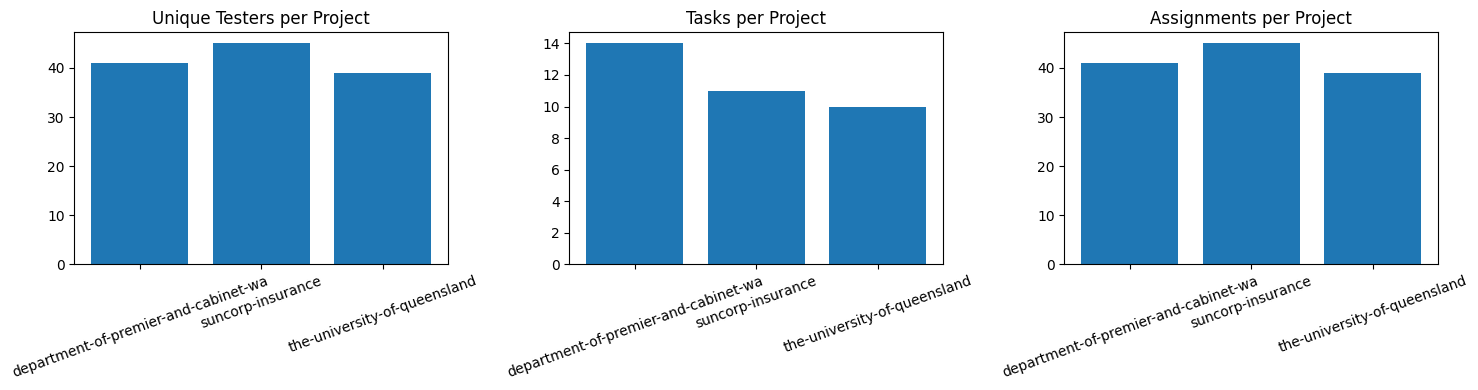

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(project_summary["project"], project_summary["n_testers"])
axes[0].set_title("Unique Testers per Project")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(project_summary["project"], project_summary["n_tasks"])
axes[1].set_title("Tasks per Project")
axes[1].tick_params(axis="x", rotation=20)

axes[2].bar(project_summary["project"], project_summary["n_assignments"])
axes[2].set_title("Assignments per Project")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [37]:
tester_project_counts = (
    tester_video_mapping[["tester_name", "project"]]
    .drop_duplicates()
    .groupby("tester_name")
    .size()
    .reset_index(name="n_projects")
    .sort_values(["n_projects", "tester_name"], ascending=[False, True])
)

tester_project_counts.head(20)

,tester_name,n_projects
0,Sharelinsonny,1
1,ghum,1


In [46]:
cross_project_dist = (
    tester_project_counts["n_projects"]
    .value_counts()
    .sort_index()
    .reset_index()
)
cross_project_dist.columns = ["n_projects", "n_testers"]
cross_project_dist

,n_projects,n_testers
0,1,2


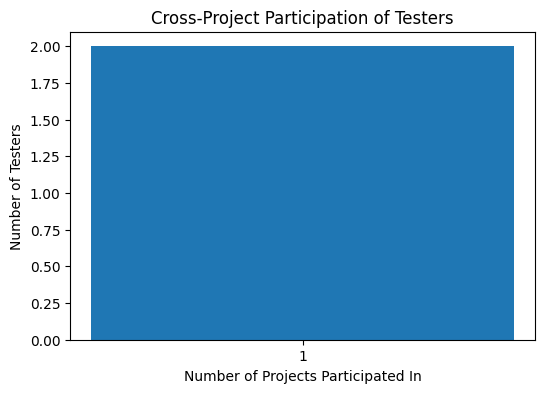

In [47]:
plt.figure(figsize=(6, 4))
plt.bar(cross_project_dist["n_projects"].astype(str), cross_project_dist["n_testers"])
plt.title("Cross-Project Participation of Testers")
plt.xlabel("Number of Projects Participated In")
plt.ylabel("Number of Testers")
plt.show()

In [48]:
tester_project_matrix = (
    tester_video_mapping.assign(value=1)
    .pivot_table(
        index="tester_name",
        columns="project",
        values="value",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

tester_project_matrix.head(20)

project,tester_name,department-of-premier-and-cabinet-wa
0,Sharelinsonny,1
1,ghum,1


In [49]:
if task_title_col is not None:
    task_type_dist = (
        tasks_df.groupby(["project", task_title_col])
        .size()
        .reset_index(name="count")
        .sort_values(["project", "count"], ascending=[True, False])
    )
    task_type_dist.head(30)
else:
    print("No task title column found.")

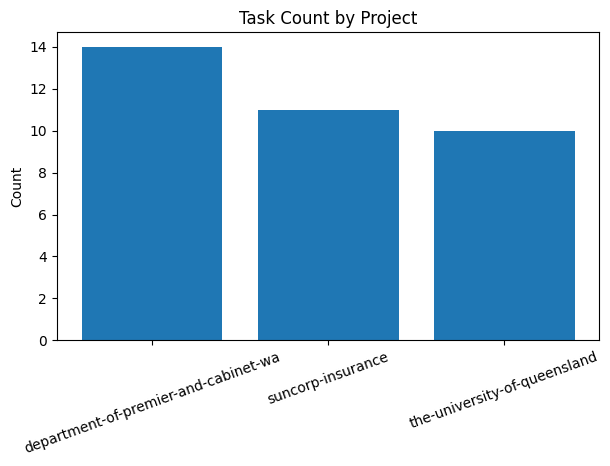

In [50]:
task_count_plot = (
    tasks_df.groupby("project")
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(7, 4))
plt.bar(task_count_plot["project"], task_count_plot["count"])
plt.title("Task Count by Project")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

In [51]:
timeguide_summary = (
    tasks_df.groupby("project")["timeguide_minutes"]
    .describe()
)

timeguide_summary

,count,mean,std,min,25%,50%,75%,max
project,,,,,,,,
department-of-premier-and-cabinet-wa,14.0,9.357143,4.601123,1.0,6.25,10.0,10.00,20.0
suncorp-insurance,11.0,13.636364,5.954372,10.0,10.00,10.0,15.00,30.0
the-university-of-queensland,10.0,16.600000,11.644741,1.0,15.00,15.0,18.75,45.0


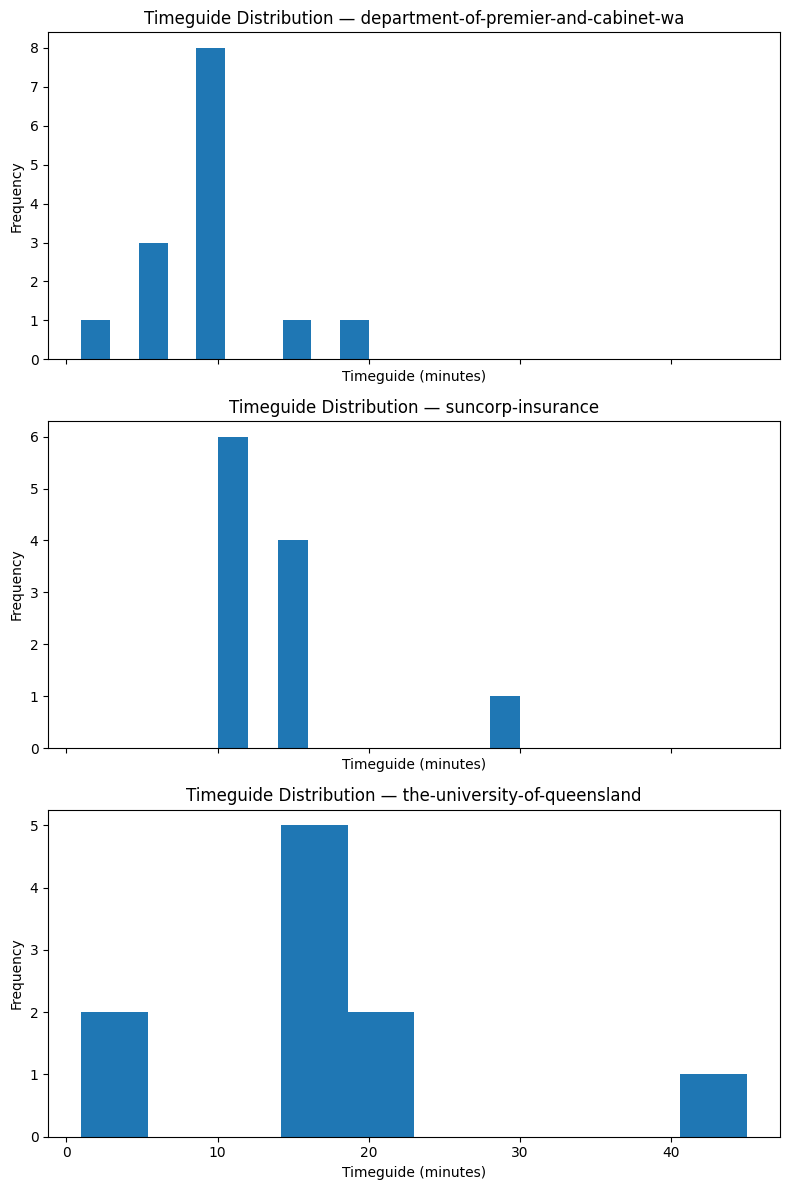

In [52]:
projects = tasks_df["project"].dropna().unique()

fig, axes = plt.subplots(len(projects), 1, figsize=(8, 4 * len(projects)), sharex=True)

if len(projects) == 1:
    axes = [axes]

for ax, project in zip(axes, projects):
    subset = tasks_df.loc[tasks_df["project"] == project, "timeguide_minutes"].dropna()
    ax.hist(subset, bins=10)
    ax.set_title(f"Timeguide Distribution — {project}")
    ax.set_xlabel("Timeguide (minutes)")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

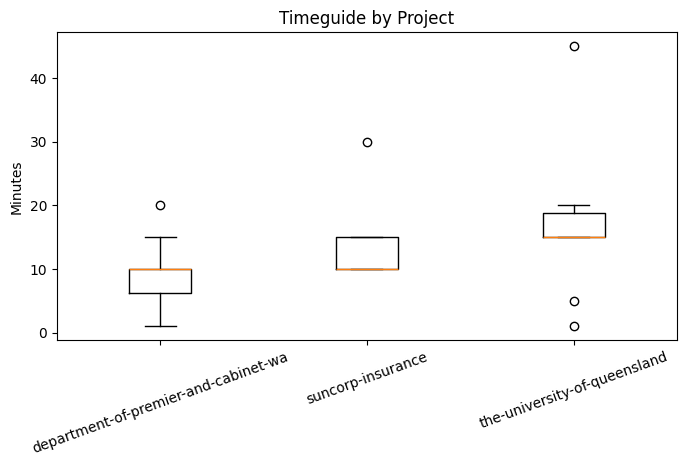

In [53]:
plt.figure(figsize=(8, 4))
plot_data = [tasks_df.loc[tasks_df["project"] == p, "timeguide_minutes"].dropna() for p in projects]
plt.boxplot(plot_data, tick_labels=projects)
plt.title("Timeguide by Project")
plt.ylabel("Minutes")
plt.xticks(rotation=20)
plt.show()

In [ ]:
video_metadata.head()

In [54]:
video_meta_summary = (
    video_metadata.groupby("project")
    .agg(
        n_videos=("video_filename", "nunique"),
        avg_duration_seconds=("duration_seconds", "mean"),
        avg_duration_ratio=("duration_ratio", "mean"),
        median_duration_ratio=("duration_ratio", "median")
    )
    .reset_index()
)

video_meta_summary

,project,n_videos,avg_duration_seconds,avg_duration_ratio,median_duration_ratio
0,department-of-premier-and-cabinet-wa,4,5137.285000,8.562150,8.81490
1,suncorp-insurance,5,3857.984000,4.286640,5.25830
2,the-university-of-queensland,6,4372.013333,4.857783,5.27005


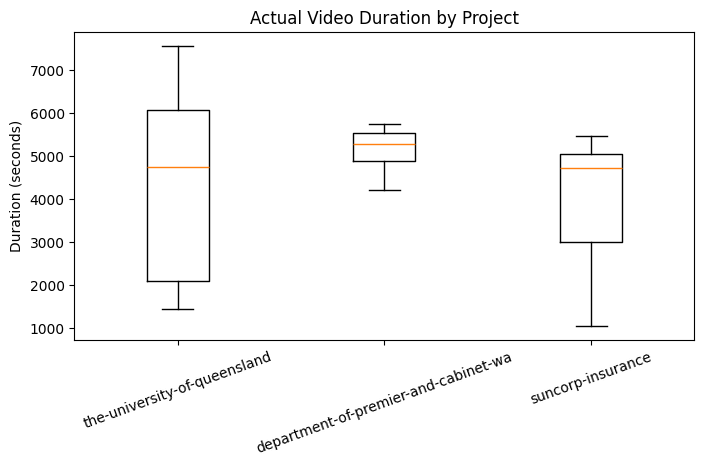

In [55]:
plt.figure(figsize=(8, 4))
plot_data = [video_metadata.loc[video_metadata["project"] == p, "duration_seconds"].dropna() for p in video_metadata["project"].dropna().unique()]
labels = list(video_metadata["project"].dropna().unique())

plt.boxplot(plot_data, tick_labels=labels)
plt.title("Actual Video Duration by Project")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=20)
plt.show()

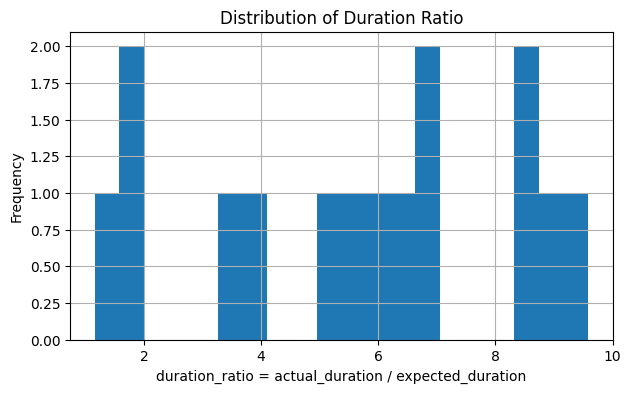

In [56]:
plt.figure(figsize=(7, 4))
video_metadata["duration_ratio"].dropna().hist(bins=20)
plt.title("Distribution of Duration Ratio")
plt.xlabel("duration_ratio = actual_duration / expected_duration")
plt.ylabel("Frequency")
plt.show()

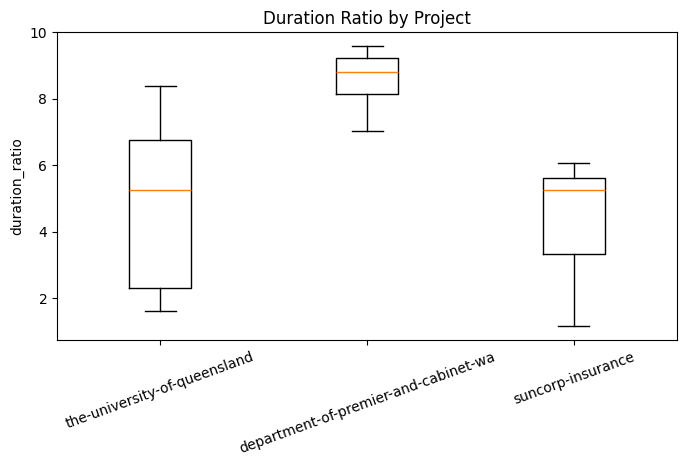

In [57]:
plt.figure(figsize=(8, 4))
plot_data = [video_metadata.loc[video_metadata["project"] == p, "duration_ratio"].dropna() for p in video_metadata["project"].dropna().unique()]
labels = list(video_metadata["project"].dropna().unique())

plt.boxplot(plot_data, tick_labels=labels)
plt.title("Duration Ratio by Project")
plt.ylabel("duration_ratio")
plt.xticks(rotation=20)
plt.show()

In [58]:
extreme_cases = video_metadata[
    (video_metadata["duration_ratio"].notna()) &
    ((video_metadata["duration_ratio"] < 0.5) | (video_metadata["duration_ratio"] > 2.0))
].sort_values("duration_ratio")

extreme_cases[["project", "video_filename", "tester_name", "duration_seconds", "duration_ratio"]]

,project,video_filename,tester_name,duration_seconds,duration_ratio
10,suncorp-insurance,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_reneerussell99_video.mp4,reneerussell99,2993.00,3.3256
5,the-university-of-queensland,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_reneerussell99_video.mp4,reneerussell99,3624.60,4.0273
11,suncorp-insurance,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_ramazankawish_video.mp4,ramazankawish,4732.49,5.2583
12,suncorp-insurance,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_terryaflint17_video.mp4,terryaflint17,5055.30,5.6170
13,suncorp-insurance,project_73052603-e4d8-4aed-a9ce-cc5db15e6355_ghum_video.mp4,ghum,5466.90,6.0743
4,the-university-of-queensland,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_ghum_video.mp4,ghum,5861.50,6.5128
1,the-university-of-queensland,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_terryaflint17_video.mp4,terryaflint17,6154.40,6.8382
9,department-of-premier-and-cabinet-wa,project_1f7f2859-ac90-4696-b89f-1077aa6040be_reneerussell99_video.mp4,reneerussell99,4223.70,7.0395
0,the-university-of-queensland,project_8aeb4cdb-106f-47c1-b6e6-867344ce673b_ramazankawish_video.mp4,ramazankawish,7558.28,8.3981
7,department-of-premier-and-cabinet-wa,project_1f7f2859-ac90-4696-b89f-1077aa6040be_terryaflint17_video.mp4,terryaflint17,5100.40,8.5007


In [59]:
final_summary = project_summary.merge(
    video_meta_summary[["project", "n_videos", "avg_duration_ratio", "median_duration_ratio"]],
    on="project",
    how="left"
)

final_summary

,project,n_testers,n_tasks,n_assignments,n_videos,avg_duration_ratio,median_duration_ratio
0,department-of-premier-and-cabinet-wa,41,14,41,4,8.562150,8.81490
1,suncorp-insurance,45,11,45,5,4.286640,5.25830
2,the-university-of-queensland,39,10,39,6,4.857783,5.27005


## Key Findings

### 1. Project scale
- The three projects differ in the number of testers, tasks, and assignments.
- This indicates that data volume and task complexity are not evenly distributed across projects.

### 2. Cross-project tester participation
- Most testers participate in only one project / some testers participate across multiple projects.
- Cross-project testers are valuable for future performance tracking because they provide repeated observations across contexts.

### 3. Task and Timeguide distribution
- Timeguide values vary across tasks and projects, showing that expected task duration is heterogeneous.
- This suggests that later evaluation should normalize by task expectation rather than using raw video duration only.

### 4. Video duration vs Timeguide deviation
- The duration_ratio distribution highlights videos that are much shorter or much longer than expected.
- Extreme low values may indicate incomplete narration or early stopping, while high values may indicate off-task exploration or inefficiency.

## Limitations

- This notebook focuses only on structured-data EDA for Step 2.2.
- It does not analyze transcript content, audio confidence, or Layer 1 flags in depth.
- Duration-based comparisons rely on `video_metadata.csv`, which is generated upstream from the metadata extraction module.